Cell 1 — imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown

from minicv.io import read_image
from minicv.transforms import resize, rotate, translate

Cell 2 — Image picker

In [2]:
def pick_image():
    root = tk.Tk()
    root.withdraw()
    root.attributes("-topmost", True)
    path = filedialog.askopenfilename(
        title="Select an image for transformations",
        filetypes=[("Image files", "*.png *.jpg *.jpeg")]
    )
    root.destroy()
    return path

IMAGE_PATH = pick_image()
img_gray = read_image(IMAGE_PATH, mode="gray")
img_rgb = read_image(IMAGE_PATH, mode="rgb")
print(f"Loaded Image: {img_gray.shape}")

Loaded Image: (588, 1400)


Cell 3 — resizing

In [3]:
h, w = img_gray.shape

@interact(
    new_h=IntSlider(min=10, max=h*2, step=10, value=h//2),
    new_w=IntSlider(min=10, max=w*2, step=10, value=w//2),
    method=Dropdown(options=["bilinear", "nearest"], value="bilinear")
)
def update_resize(new_h, new_w, method):
    resized = resize(img_gray, out_h=new_h, out_w=new_w, method=method)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(resized, cmap="gray")
    plt.title(f"Resized to {new_w}x{new_h} using {method}")
    plt.axis("off")
    plt.show()

interactive(children=(IntSlider(value=294, description='new_h', max=1176, min=10, step=10), IntSlider(value=70…

Cell 4 - Rotation

In [ ]:
@interact(
    angle=FloatSlider(min=-180, max=180, step=1, value=0),
    method=Dropdown(options=["bilinear", "nearest"], value="bilinear")
)
def update_rotate(angle, method):
    rotated = rotate(img_gray, angle=angle, method=method)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(rotated, cmap="gray")
    plt.title(f"Rotated {angle}° using {method}")
    plt.axis("off")
    plt.show()

interactive(children=(FloatSlider(value=0.0, description='angle', max=180.0, min=-180.0, step=1.0), Dropdown(d…

Cell 4 — Interactive Translation

In [ ]:
h, w = img_gray.shape

@interact(
    tx=IntSlider(min=-w, max=w, step=5, value=0, description="Shift X"),
    ty=IntSlider(min=-h, max=h, step=5, value=0, description="Shift Y")
)
def update_translate(tx, ty):
    shifted = translate(img_gray, shift_x=tx, shift_y=ty)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(shifted, cmap="gray")
    plt.title(f"Translated by x={tx}, y={ty}")
    plt.axis("off")
    plt.show()

interactive(children=(IntSlider(value=0, description='Shift X', max=1400, min=-1400, step=5), IntSlider(value=…

Cell 6 - RGB Test

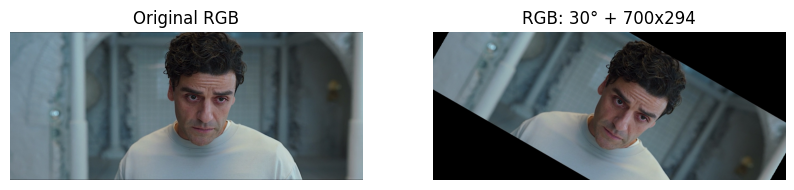

In [8]:
test_angle = 30
test_h, test_w = img_rgb.shape[0] // 2, img_rgb.shape[1] // 2

# Chain the operations
img_step1 = rotate(img_rgb, angle=test_angle, method="bilinear")
img_step2 = resize(img_step1, out_h=test_h, out_w=test_w, method="bilinear")

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original RGB")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(np.clip(img_step2, 0, 255).astype(np.uint8))
plt.title(f"RGB: {test_angle}° + {test_w}x{test_h}")
plt.axis("off")

plt.show()